# Creating Cohorts of Songs (Clustering ML Project)
### Rolling Stones Spotify Dataset

## Objective
Spotify wants to create **cohorts (clusters)** of songs based on audio features so that similar songs can be recommended together.

This project will:
1. Inspect and clean the dataset
2. Perform EDA (Exploratory Data Analysis)
3. Analyze popularity patterns over time
4. Apply dimensionality reduction (PCA)
5. Perform clustering (KMeans)
6. Interpret clusters as meaningful song cohorts

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
import os
print("Current Working Directory:", os.getcwd())
print("Files in this directory:\n", os.listdir())

Current Working Directory: C:\Users\viswa\OneDrive\Documents\E & ICT Academy, IIT Kanpur Generative AI & Machine Learning program\Projects\IITK AIML Machine Learning\Creating Cohorts of Songs
Files in this directory:
 ['.ipynb_checkpoints', '.~Creating Cohorts of Songs_Clustering ML.ipynb', '1736848576_creating_cohorts_of_songs_problem_statement.docx', 'Creating Cohorts of Songs_Clustering ML.ipynb', 'Data Dictionary - Creating cohorts of songs.xlsx', 'rolling_stones_spotify.csv', 'Untitled.ipynb']


In [4]:
import os
from pathlib import Path

# Notebook folder
notebook_dir = Path().resolve()
print("Notebook directory:", notebook_dir)

# CSV full path
csv_path = notebook_dir / "rolling_stones_spotify.csv"
print("CSV path:", csv_path)
print("CSV exists:", csv_path.exists())


Notebook directory: C:\Users\viswa\OneDrive\Documents\E & ICT Academy, IIT Kanpur Generative AI & Machine Learning program\Projects\IITK AIML Machine Learning\Creating Cohorts of Songs
CSV path: C:\Users\viswa\OneDrive\Documents\E & ICT Academy, IIT Kanpur Generative AI & Machine Learning program\Projects\IITK AIML Machine Learning\Creating Cohorts of Songs\rolling_stones_spotify.csv
CSV exists: True


In [8]:
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()

Shape: (1610, 18)


,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1610.0,NaN,NaN,NaN,804.5,464.911282,0.0,402.25,804.5,1206.75,1609.0
name,1610,954,Brown Sugar - Live,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album,1610,90,Voodoo Lounge Uncut (Live),56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,1610,57,1972-05-12,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_number,1610.0,NaN,NaN,NaN,8.613665,6.56022,1.0,4.0,7.0,11.0,47.0
id,1610,1610,43SkTJJ2xleDaeiE4TIM70,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uri,1610,1610,spotify:track:43SkTJJ2xleDaeiE4TIM70,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acousticness,1610.0,NaN,NaN,NaN,0.250475,0.227397,0.000009,0.05835,0.183,0.40375,0.994
danceability,1610.0,NaN,NaN,NaN,0.46886,0.141775,0.104,0.36225,0.458,0.578,0.887
energy,1610.0,NaN,NaN,NaN,0.792352,0.179886,0.141,0.674,0.8485,0.945,0.999


## Initial Data Quality Checks

We check:
- Missing values
- Duplicates
- Unique albums / songs

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
print("Unique songs:", df["name"].nunique())
print("Unique albums:", df["album"].nunique())
print("Unique artists:", df["artist"].nunique() if "artist" in df.columns else "artist column not present")

Unique songs: 954
Unique albums: 90
Unique artists: artist column not present


In [14]:
df.columns

Index(['Unnamed: 0', 'name', 'album', 'release_date', 'track_number', 'id',
       'uri', 'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity',
       'duration_ms'],
      dtype='object')

## Data Cleaning

In this step we:
- Remove irrelevant identifier columns
- Convert release_date to datetime
- Verify missing values and duplicates

In [15]:
df = df.drop(columns=["Unnamed: 0"])
df.head()

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [18]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
# safety: create release_year if not exists
if "release_year" not in df.columns:
    df["release_year"] = df["release_date"].dt.year
df[["release_date", "release_year"]].head()

,release_date,release_year
0,2022-06-10,2022
1,2022-06-10,2022
2,2022-06-10,2022
3,2022-06-10,2022
4,2022-06-10,2022


In [19]:
df.isnull().sum().sort_values(ascending=False).head(20)

name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
release_year        0
dtype: int64

In [20]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [21]:
df.dtypes

name                        object
album                       object
release_date        datetime64[ns]
track_number                 int64
id                          object
uri                         object
acousticness               float64
danceability               float64
energy                     float64
instrumentalness           float64
liveness                   float64
loudness                   float64
speechiness                float64
tempo                      float64
valence                    float64
popularity                   int64
duration_ms                  int64
release_year                 int32
dtype: object

## Feature Engineering

We create a `release_year` column from `release_date` to analyze trends over time.

In [22]:
df["release_year"] = df["release_date"].dt.year
df[["release_date", "release_year"]].head()

,release_date,release_year
0,2022-06-10,2022
1,2022-06-10,2022
2,2022-06-10,2022
3,2022-06-10,2022
4,2022-06-10,2022


## Defining Popular Songs

Spotify popularity ranges from 0 to 100.
We define:
- Popular song: popularity >= 60

In [23]:
POPULARITY_THRESHOLD = 60
df["is_popular"] = (df["popularity"] >= POPULARITY_THRESHOLD).astype(int)

df["is_popular"].value_counts()

is_popular
0    1594
1      16
Name: count, dtype: int64

## Top 2 Albums Recommendation (based on number of popular songs)

We count how many "popular" songs each album contains and recommend the top 2 albums.

In [24]:
album_popular_count = (
    df.groupby("album")["is_popular"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"is_popular": "popular_song_count"})
)

album_popular_count.head(10)

,album,popular_song_count
0,Sticky Fingers (Remastered),3
1,Aftermath,2
2,Let It Bleed,2
3,Some Girls,2
4,Between The Buttons,1
5,Out Of Our Heads,1
6,Exile On Main Street (2010 Re-Mastered),1
7,Bridges To Babylon (Remastered),1
8,Tattoo You (2009 Re-Mastered),1
9,Beggars Banquet (50th Anniversary Edition),1


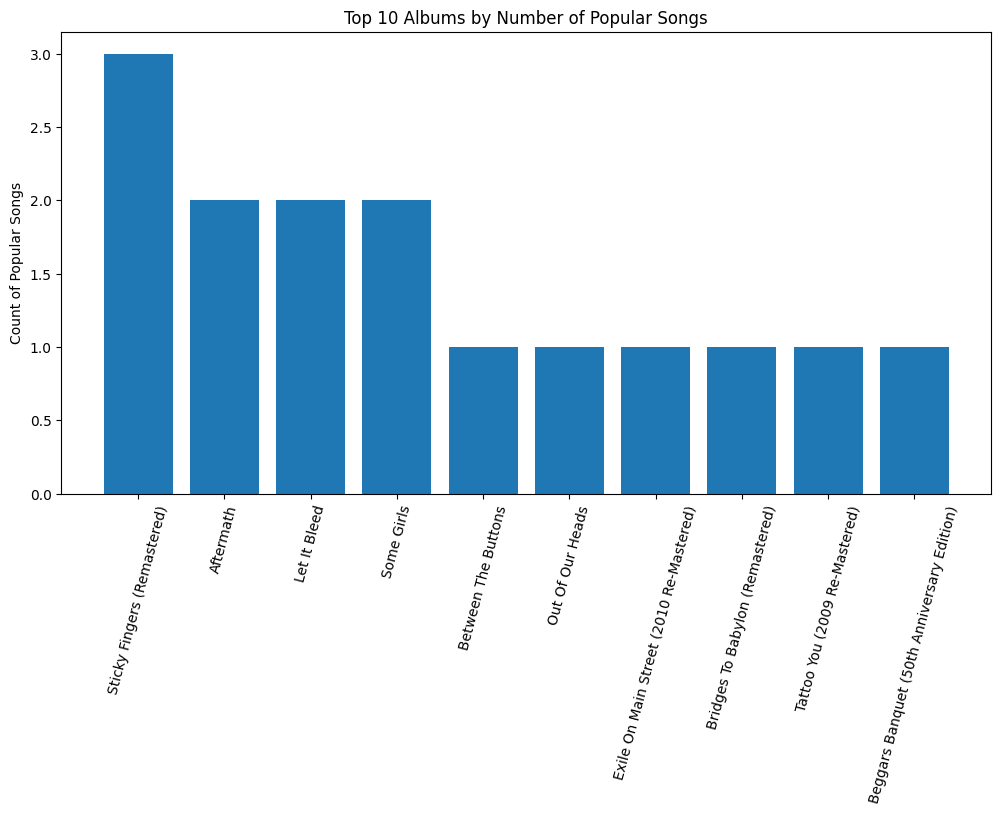

In [25]:
plt.figure(figsize=(12,6))
plt.bar(album_popular_count["album"][:10], album_popular_count["popular_song_count"][:10])
plt.xticks(rotation=75)
plt.title("Top 10 Albums by Number of Popular Songs")
plt.ylabel("Count of Popular Songs")
plt.show()

In [26]:
top2_albums = album_popular_count.head(2)
top2_albums

,album,popular_song_count
0,Sticky Fingers (Remastered),3
1,Aftermath,2


### Recommendation
Based on the dataset, the **Top 2 recommended albums** are those with the highest number of songs having popularity ≥ 60.

These albums have the maximum concentration of high-performing tracks and are ideal candidates for:
- Spotify editorial playlist promotion
- artist highlight campaigns
- recommendation engine seeding

## Improved definition of Popular Songs (Adaptive Threshold)

Since only a small number of songs have popularity ≥ 60, we define popular songs using a percentile-based rule.

We define:
- Popular songs = songs with popularity in the **top 10%** of the dataset.

In [27]:
popularity_cutoff = df["popularity"].quantile(0.90)
popularity_cutoff

np.float64(36.0)

In [28]:
df["is_popular"] = (df["popularity"] >= popularity_cutoff).astype(int)
df["is_popular"].value_counts()

is_popular
0    1434
1     176
Name: count, dtype: int64

In [29]:
album_popular_count = (
    df.groupby("album")["is_popular"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"is_popular": "popular_song_count"})
)

album_popular_count.head(10)

,album,popular_song_count
0,Exile On Main Street (2010 Re-Mastered),18
1,Beggars Banquet (50th Anniversary Edition),10
2,Some Girls,10
3,Sticky Fingers (Remastered),10
4,Tattoo You (2009 Re-Mastered),10
5,Let It Bleed,9
6,Honk (Deluxe),8
7,Let It Bleed (50th Anniversary Edition / Remas...,6
8,Aftermath,6
9,Black And Blue (Remastered 2009),5


In [30]:
top2_albums = album_popular_count.head(2)
top2_albums

,album,popular_song_count
0,Exile On Main Street (2010 Re-Mastered),18
1,Beggars Banquet (50th Anniversary Edition),10


## Dataset Uniqueness Check

The dataset contains multiple versions of the same song (remastered/live/compilations).
We inspect uniqueness across:
- Spotify track id
- song name
- song name + album

In [31]:
print("Total rows:", len(df))
print("Unique Spotify track IDs:", df["id"].nunique())
print("Unique song names:", df["name"].nunique())
print("Unique (name, album):", df[["name", "album"]].drop_duplicates().shape[0])

Total rows: 1610
Unique Spotify track IDs: 1610
Unique song names: 954
Unique (name, album): 1508


## Exploratory Data Analysis (EDA)

We explore:
- distributions of audio features
- correlation patterns
- how popularity relates to these features

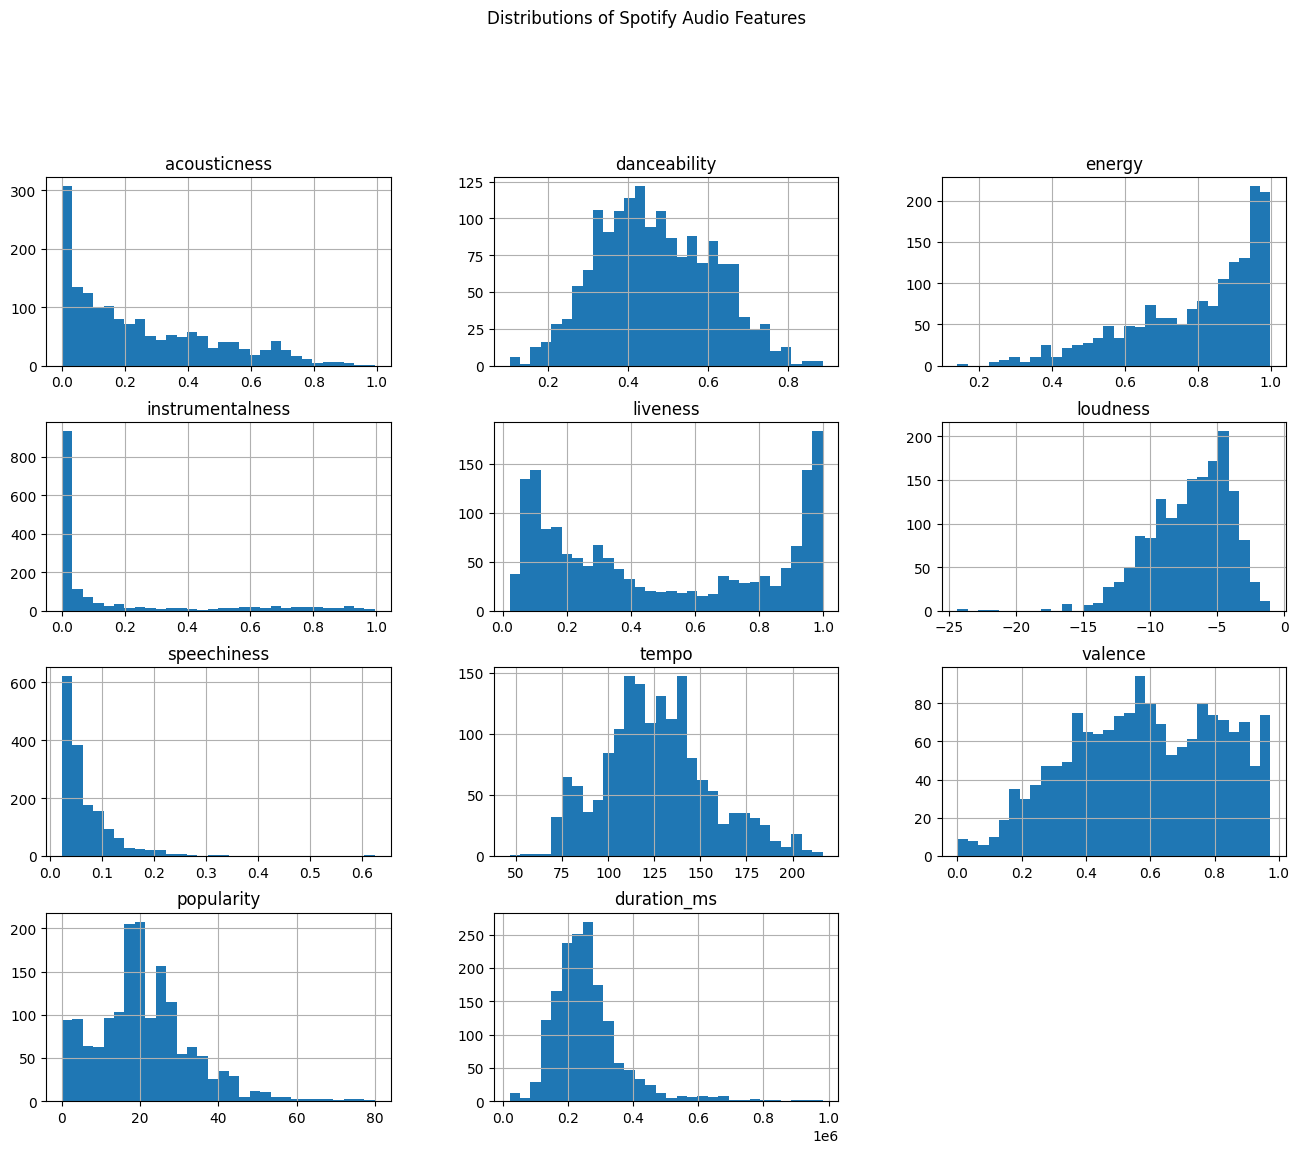

In [32]:
audio_features = [
    "acousticness","danceability","energy","instrumentalness",
    "liveness","loudness","speechiness","tempo","valence",
    "popularity","duration_ms"
]

df[audio_features].hist(bins=30, figsize=(16,12))
plt.suptitle("Distributions of Spotify Audio Features", y=1.02)
plt.show()

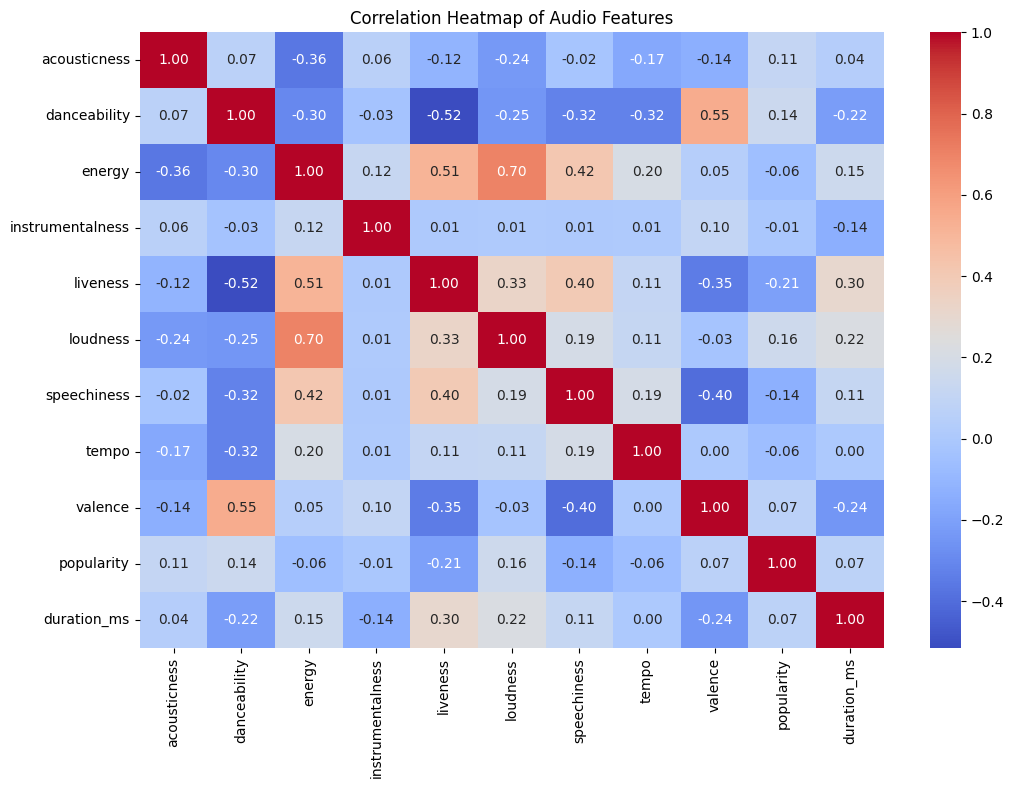

In [33]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df[audio_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Audio Features")
plt.show()

In [34]:
pop_corr = df[audio_features].corr()["popularity"].sort_values(ascending=False)
pop_corr

popularity          1.000000
loudness            0.156323
danceability        0.141205
acousticness        0.108046
duration_ms         0.074102
valence             0.065333
instrumentalness   -0.010612
energy             -0.057272
tempo              -0.061061
speechiness        -0.136745
liveness           -0.205845
Name: popularity, dtype: float64

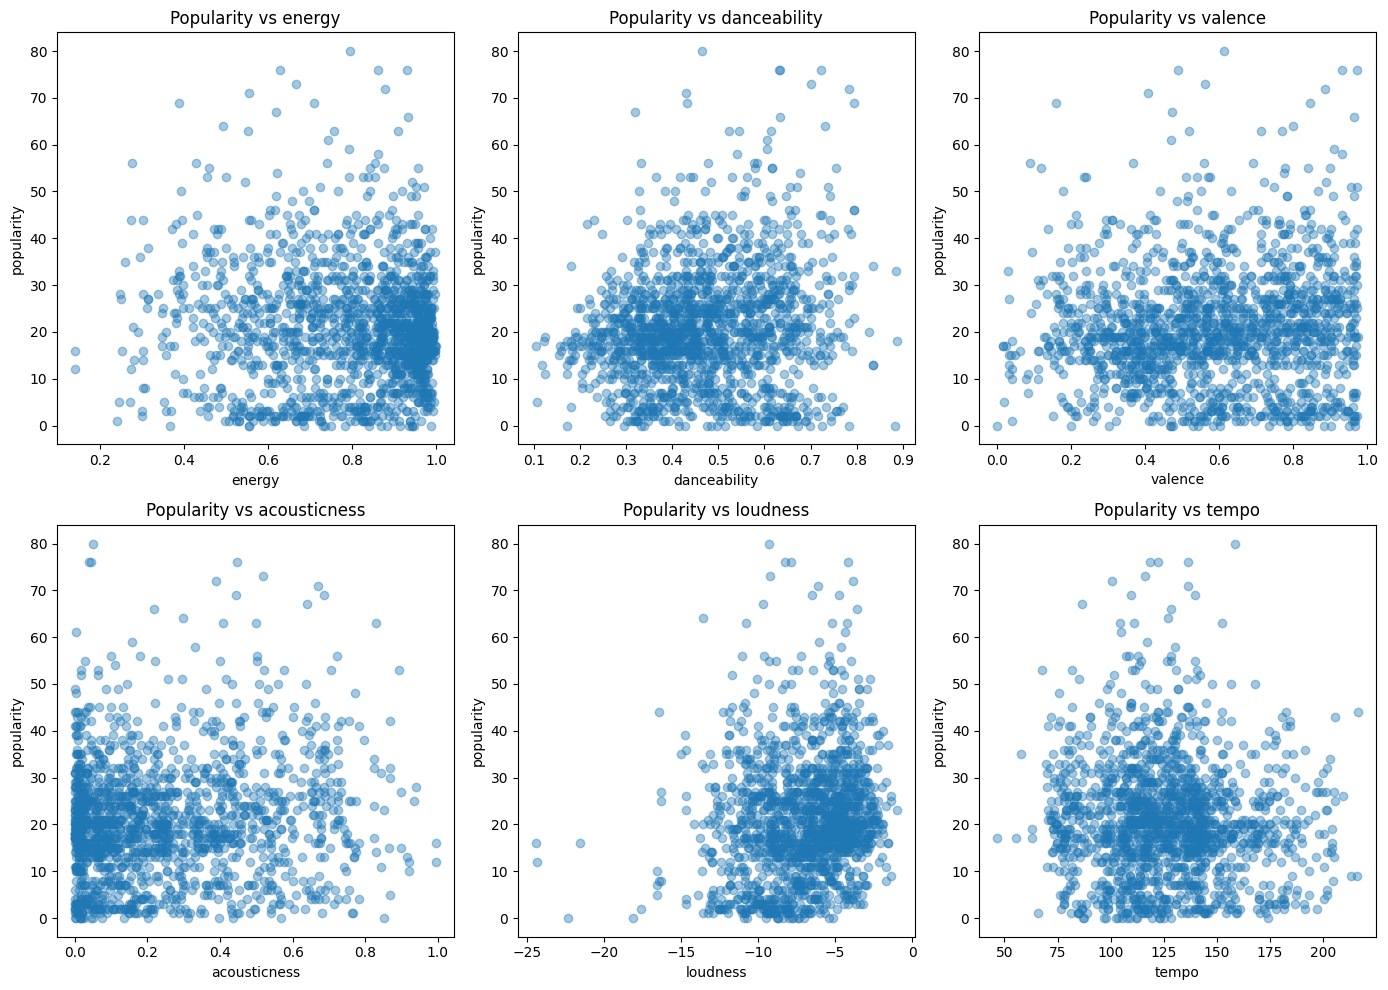

In [35]:
top_features = ["energy", "danceability", "valence", "acousticness", "loudness", "tempo"]

plt.figure(figsize=(14,10))
for i, col in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    plt.scatter(df[col], df["popularity"], alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("popularity")
    plt.title(f"Popularity vs {col}")
plt.tight_layout()
plt.show()

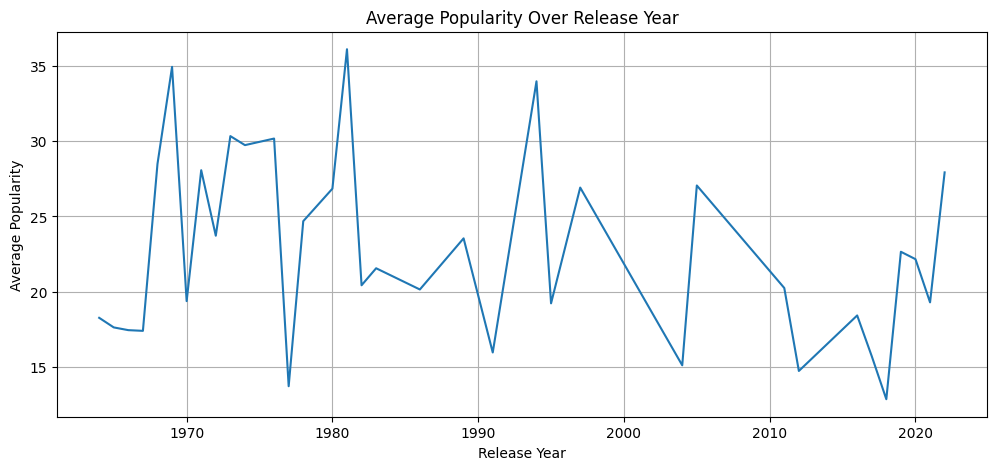

In [36]:
yearly_popularity = (
    df.groupby("release_year")["popularity"]
    .mean()
    .reset_index()
    .sort_values("release_year")
)

plt.figure(figsize=(12,5))
plt.plot(yearly_popularity["release_year"], yearly_popularity["popularity"])
plt.title("Average Popularity Over Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Popularity")
plt.grid(True)
plt.show()

## Dimensionality Reduction (PCA)

Spotify audio features contain multiple dimensions (tempo, loudness, energy, etc.).
To better visualize and cluster the data, we apply **PCA (Principal Component Analysis)**:

- PCA converts the original correlated features into a smaller number of **principal components**
- Each component captures maximum possible variance
- Benefits:
  - reduces noise
  - improves clustering stability
  - enables 2D visualization of song cohorts

In [37]:
features_for_clustering = [
    "acousticness","danceability","energy","instrumentalness",
    "liveness","loudness","speechiness","tempo","valence",
    "duration_ms"
]

X = df[features_for_clustering].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(1610, 10)

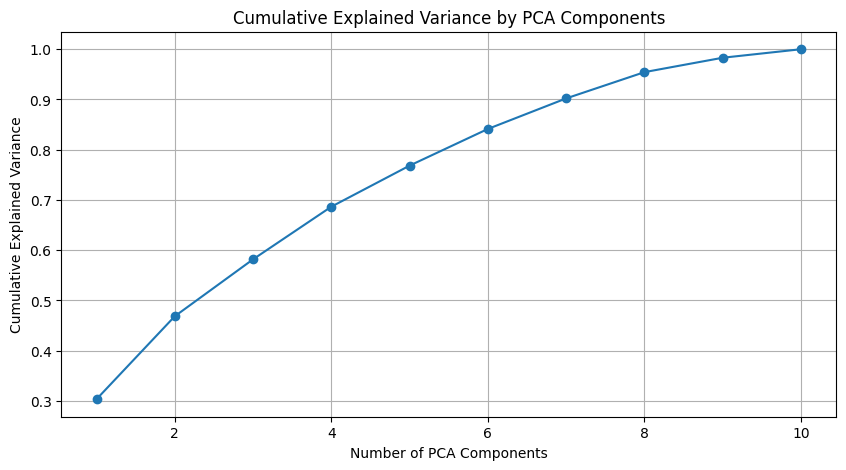

In [38]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker="o")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [39]:
n_components_90 = np.argmax(explained_var >= 0.90) + 1
print("No. of components to explain 90% variance:", n_components_90)

No. of components to explain 90% variance: 7


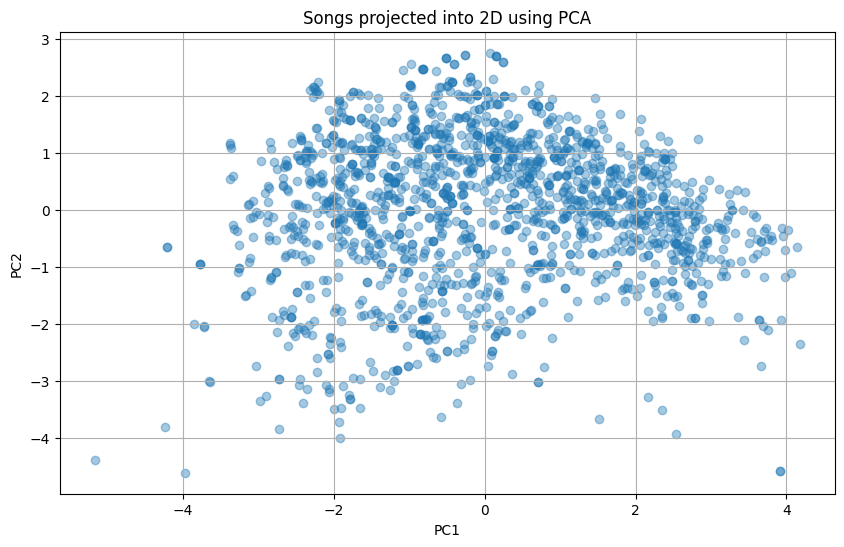

In [40]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], alpha=0.4)
plt.title("Songs projected into 2D using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

## KMeans Clustering - Selecting Optimal Number of Clusters

We use:
- Elbow method (inertia)
- Silhouette score
to select the best K value.

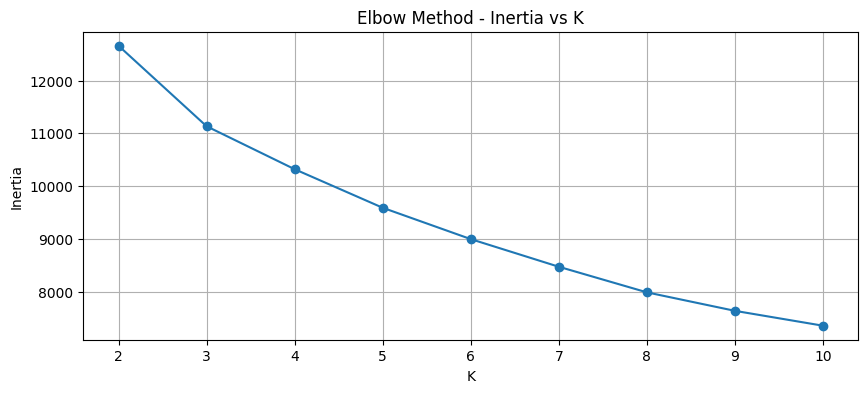

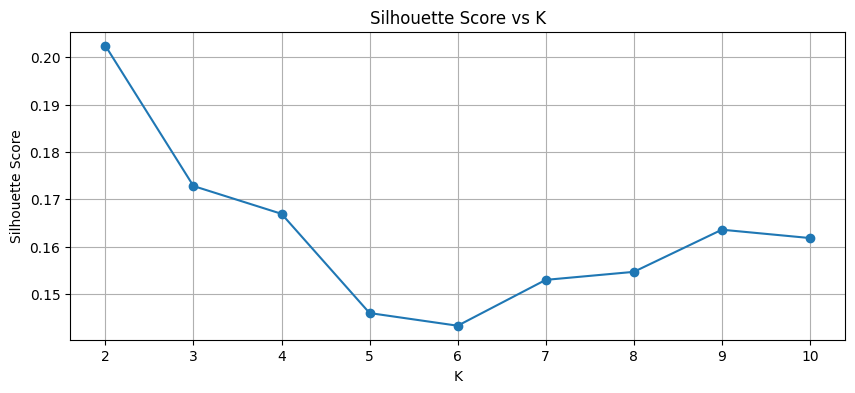

,K,Inertia,Silhouette
0,2,12657.606848,0.202414
1,3,11134.927758,0.172816
2,4,10322.583579,0.166951
3,5,9593.344846,0.146018
4,6,9000.636478,0.143346
5,7,8477.918280,0.153019
6,8,7993.978636,0.154709
7,9,7644.331108,0.163602
8,10,7363.152566,0.161841


In [42]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow plot
plt.figure(figsize=(10,4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method - Inertia vs K")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# Silhouette plot
plt.figure(figsize=(10,4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

pd.DataFrame({"K": list(K_range), "Inertia": inertias, "Silhouette": sil_scores})

## Final KMeans Model

Although K=2 produces the highest silhouette score, it is too coarse for meaningful music cohorts.
We choose **K=4** for better interpretability and actionable Spotify cohort segmentation.

In [43]:
FINAL_K = 4

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled)

df["cluster"].value_counts().sort_index()

cluster
0    376
1    532
2    197
3    505
Name: count, dtype: int64

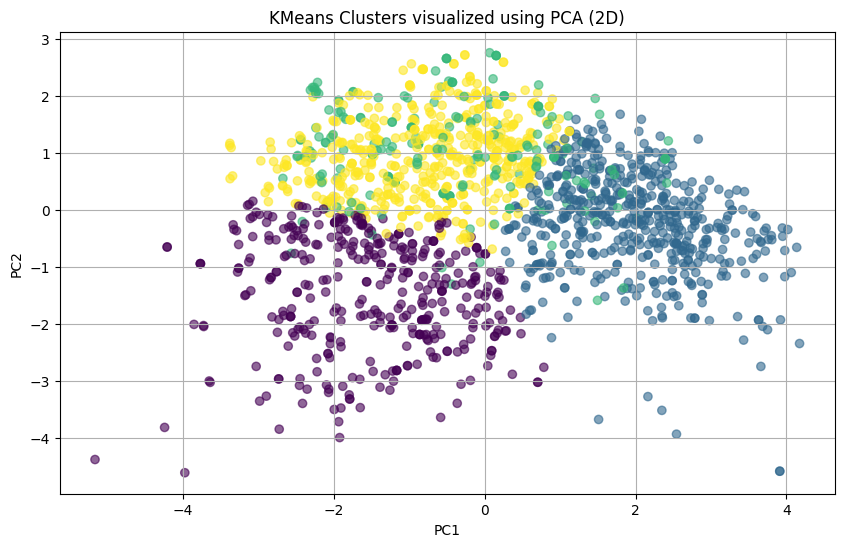

In [44]:
plt.figure(figsize=(10,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=df["cluster"], alpha=0.6)
plt.title("KMeans Clusters visualized using PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

## Cluster Profiling

We analyze the average feature values per cluster to understand what each cohort represents.
This helps interpret clusters as real-world music groups like:
- high energy rock tracks
- acoustic mellow tracks
- live performance tracks
- etc.

In [45]:
cluster_profile = df.groupby("cluster")[features_for_clustering + ["popularity"]].mean().round(3)
cluster_profile

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity
cluster,,,,,,,,,,,
0,0.456,0.492,0.559,0.076,0.294,-9.810,0.047,113.273,0.469,244422.085,22.213
1,0.194,0.359,0.925,0.111,0.845,-5.316,0.109,137.156,0.439,314265.547,17.773
2,0.248,0.507,0.832,0.752,0.420,-6.771,0.055,125.841,0.723,201904.787,21.168
3,0.158,0.553,0.811,0.057,0.295,-6.680,0.050,124.047,0.762,229878.273,22.756


In [46]:
for c in sorted(df["cluster"].unique()):
    print(f"\n--- Cluster {c}: Top 5 songs by popularity ---")
    display(df[df["cluster"] == c][["name", "album", "release_date", "popularity"]]
            .sort_values("popularity", ascending=False)
            .head(5))


--- Cluster 0: Top 5 songs by popularity ---


,name,album,release_date,popularity
1248,Gimme Shelter,Let It Bleed,1969-12-05,76
1257,Sympathy For The Devil - 50th Anniversary Edition,Beggars Banquet (50th Anniversary Edition),1968-12-06,73
1023,Angie,Goats Head Soup (Remastered 2009),1973-08-31,71
1122,Wild Horses - 2009 Mix,Sticky Fingers (Remastered),1971-04-23,69
1256,You Can't Always Get What You Want,Let It Bleed,1969-12-05,67



--- Cluster 1: Top 5 songs by popularity ---


,name,album,release_date,popularity
1094,Loving Cup,Exile On Main Street (Deluxe Version),1972-05-12,50
1565,Time Is On My Side - Mono Version / Organ Intro,12 X 5,1964-10-17,44
697,Like A Rolling Stone - Live / Remastered 2009,Stripped,1995-01-13,43
1047,Loving Cup,Exile On Main Street (2010 Re-Mastered),1972-05-12,42
829,Undercover (Of The Night) - Remastered 2009,Undercover (2009 Re-Mastered),1983-11-07,42



--- Cluster 2: Top 5 songs by popularity ---


,name,album,release_date,popularity
1043,Tumbling Dice,Exile On Main Street (2010 Re-Mastered),1972-05-12,63
1448,Get Off Of My Cloud - Mono Version,December’s Children (And Everybody’s),1965-12-04,55
1468,The Last Time - Mono Version,Out Of Our Heads,1965-07-30,50
1040,Rip This Joint,Exile On Main Street (2010 Re-Mastered),1972-05-12,49
1095,Happy,Exile On Main Street (Deluxe Version),1972-05-12,49



--- Cluster 3: Top 5 songs by popularity ---


,name,album,release_date,popularity
1403,"Paint It, Black",Aftermath,1966-04-15,80
1472,(I Can't Get No) Satisfaction - Mono Version,Out Of Our Heads,1965-07-30,76
862,Start Me Up - Remastered 2009,Tattoo You (2009 Re-Mastered),1981-08-24,76
901,Beast Of Burden - Remastered 1994,Some Girls,1978-06-09,72
893,Miss You - Remastered,Some Girls,1978-06-09,69


In [47]:
cluster_names = {
    0: "Cohort 0",
    1: "Cohort 1",
    2: "Cohort 2",
    3: "Cohort 3"
}

df["cohort_name"] = df["cluster"].map(cluster_names)
df[["name", "album", "popularity", "cluster", "cohort_name"]].head()

,name,album,popularity,cluster,cohort_name
0,Concert Intro Music - Live,Licked Live In NYC,33,2,Cohort 2
1,Street Fighting Man - Live,Licked Live In NYC,34,1,Cohort 1
2,Start Me Up - Live,Licked Live In NYC,34,1,Cohort 1
3,If You Can't Rock Me - Live,Licked Live In NYC,32,1,Cohort 1
4,Don’t Stop - Live,Licked Live In NYC,32,1,Cohort 1


## Final Output

We output the dataset with assigned cohort labels for all songs.

In [48]:
final_output = df[[
    "name","album","release_date","track_number",
    "popularity",
    "acousticness","danceability","energy","instrumentalness","liveness",
    "loudness","speechiness","tempo","valence","duration_ms",
    "cluster","cohort_name"
]].copy()

final_output.head()

,name,album,release_date,track_number,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,cluster,cohort_name
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,33,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,48640,2,Cohort 2
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,34,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,253173,1,Cohort 1
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,34,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,263160,1,Cohort 1
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,32,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,305880,1,Cohort 1
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,32,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,305106,1,Cohort 1


In [49]:
cluster_names = {
    0: "Acoustic & Mellow Classics",
    1: "Live & Raw Stadium Rock",
    2: "Instrumental Grooves & Jams",
    3: "Upbeat Studio Hits"
}

df["cohort_name"] = df["cluster"].map(cluster_names)

df[["name","album","popularity","cluster","cohort_name"]].head()

,name,album,popularity,cluster,cohort_name
0,Concert Intro Music - Live,Licked Live In NYC,33,2,Instrumental Grooves & Jams
1,Street Fighting Man - Live,Licked Live In NYC,34,1,Live & Raw Stadium Rock
2,Start Me Up - Live,Licked Live In NYC,34,1,Live & Raw Stadium Rock
3,If You Can't Rock Me - Live,Licked Live In NYC,32,1,Live & Raw Stadium Rock
4,Don’t Stop - Live,Licked Live In NYC,32,1,Live & Raw Stadium Rock


## Cohort Summary

We summarize each cohort based on:
- size of cohort
- average feature profile
- interpretation in business terms

In [50]:
cohort_summary = (
    df.groupby(["cluster","cohort_name"])
    .agg(
        songs=("name","count"),
        avg_popularity=("popularity","mean"),
        avg_energy=("energy","mean"),
        avg_danceability=("danceability","mean"),
        avg_acousticness=("acousticness","mean"),
        avg_liveness=("liveness","mean"),
        avg_instrumentalness=("instrumentalness","mean"),
    )
    .round(3)
    .sort_values("songs", ascending=False)
)

cohort_summary

,,songs,avg_popularity,avg_energy,avg_danceability,avg_acousticness,avg_liveness,avg_instrumentalness
cluster,cohort_name,,,,,,,
1,Live & Raw Stadium Rock,532,17.773,0.925,0.359,0.194,0.845,0.111
3,Upbeat Studio Hits,505,22.756,0.811,0.553,0.158,0.295,0.057
0,Acoustic & Mellow Classics,376,22.213,0.559,0.492,0.456,0.294,0.076
2,Instrumental Grooves & Jams,197,21.168,0.832,0.507,0.248,0.420,0.752


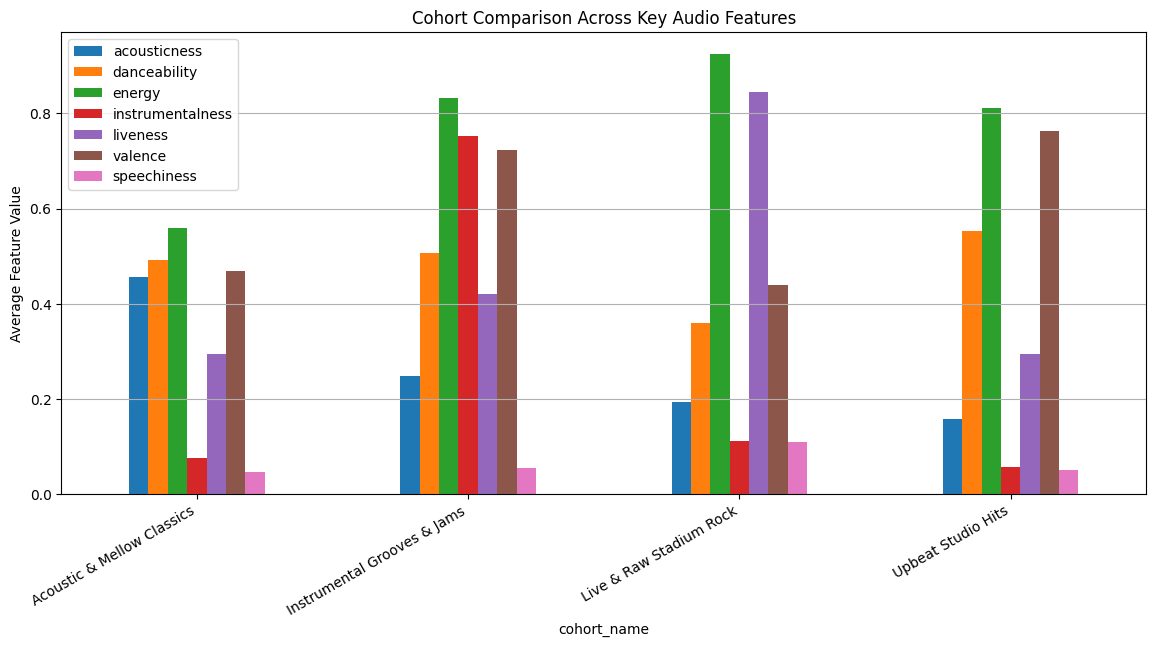

In [51]:
plot_features = ["acousticness","danceability","energy","instrumentalness","liveness","valence","speechiness"]

cluster_means = df.groupby("cohort_name")[plot_features].mean()

cluster_means.plot(kind="bar", figsize=(14,6))
plt.title("Cohort Comparison Across Key Audio Features")
plt.ylabel("Average Feature Value")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y")
plt.show()

## Conclusion & Business Recommendations

### Key Findings
- Rolling Stones songs can be grouped into **4 meaningful cohorts** using Spotify audio features.
- The cohorts are strongly distinguished by:
  - **liveness** (live vs studio)
  - **acousticness** (mellow vs rock)
  - **instrumentalness** (vocal vs jam tracks)
  - **danceability & valence** (upbeat hits)

### Spotify Use-Case Recommendations
1. **Playlist Generation**
   - Create playlists for each cohort such as:
     - “Rolling Stones: Live & Raw Stadium Rock”
     - “Rolling Stones: Acoustic & Mellow Classics”
     - “Rolling Stones: Upbeat Studio Hits”

2. **Recommendation Engine Boost**
   - When a user plays a song, recommend within the same cohort first to maximize similarity.

3. **User Mood/Activity Personalization**
   - Use cohorts for activity-based suggestions:
     - Upbeat Studio Hits → workout/driving playlists
     - Acoustic & Mellow → calm/relax playlists
     - Live & Raw → concert feel / immersive playlists

### Final Deliverable
The final dataset contains all songs with:
- cluster label
- cohort name
which can be used directly in recommendation systems.
